# Lab 20: Time Series Diagnostics and Advanced Decomposition
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [50]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install streamlit fredapi statsmodels ruptures plotly -q

In [30]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Import libraries and set FRED API key
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'c066ea2f00b7da4c373283363ea76952'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Broken STL Decomposition (15 min)

The code below pulls FRED retail sales (not seasonally adjusted) and applies
STL decomposition. The output **looks wrong** — the seasonal amplitude grows
over time, which STL (an additive method) should not produce.

**Your task:** Find the bug, explain why it produces the wrong output, and fix it.

In [12]:
# # -----------------------------------------------------------
# # GUIDED — Run as-is (contains deliberate error)
# # Step 1: STL decomposition of retail sales
# # -----------------------------------------------------------

# retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
# retail = retail.dropna()
# retail.index = pd.DatetimeIndex(retail.index)
# retail.index.freq = 'MS'

# # Apply STL directly to the raw series
# # BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# # grows proportionally with the level). STL is an ADDITIVE decomposition.
# # Applying additive STL to multiplicative data leaks growing seasonal
# # effects into the residual and distorts the seasonal component.
# stl_result = STL(retail, period=12, robust=True).fit()

# fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
# axes[0].set_ylabel('Observed')
# axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

# stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
# axes[1].set_ylabel('Trend')

# stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
# axes[2].set_ylabel('Seasonal')

# stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
# axes[3].set_ylabel('Residual')
# axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

# plt.tight_layout()
# plt.show()

# # Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# # Compute the seasonal range per year to check.
# seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
# annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
# print('Seasonal amplitude by year (should be ~constant for additive STL):')
# print(annual_range.tail(10).round(1))
# print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
# print('If this ratio >> 1, the additive assumption is violated.')

### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific assumption violation)
2. **Why does this happen?** (explain why additive STL on multiplicative data produces growing seasonal amplitude)
3. **Fix the code below.** The standard fix is: log-transform first, then apply STL to the log series.
4. **What chapter concept does this error violate?** (hint: additive vs. multiplicative decomposition)

**Verification checkpoint:** After fixing, the ratio of latest-to-earliest seasonal amplitude should be between 0.7 and 1.3 (roughly constant). If it is still > 2.0, you have not fixed the bug.

1. STL is an adding function for the retail data, what we need is a multiplicative function, or to have the retail data be log-transformed.
2. STL, by being additive, is trying to identify the spikes in data using just one single seasonal sample. However the spikes have a residual effect, which goes on to affect future seasonals, residuals, and spikes.
3. log_retail = np.log(retail)
    stl_result = STL(log_retail, period=12, robust=True).fit()
4. Ch. 20

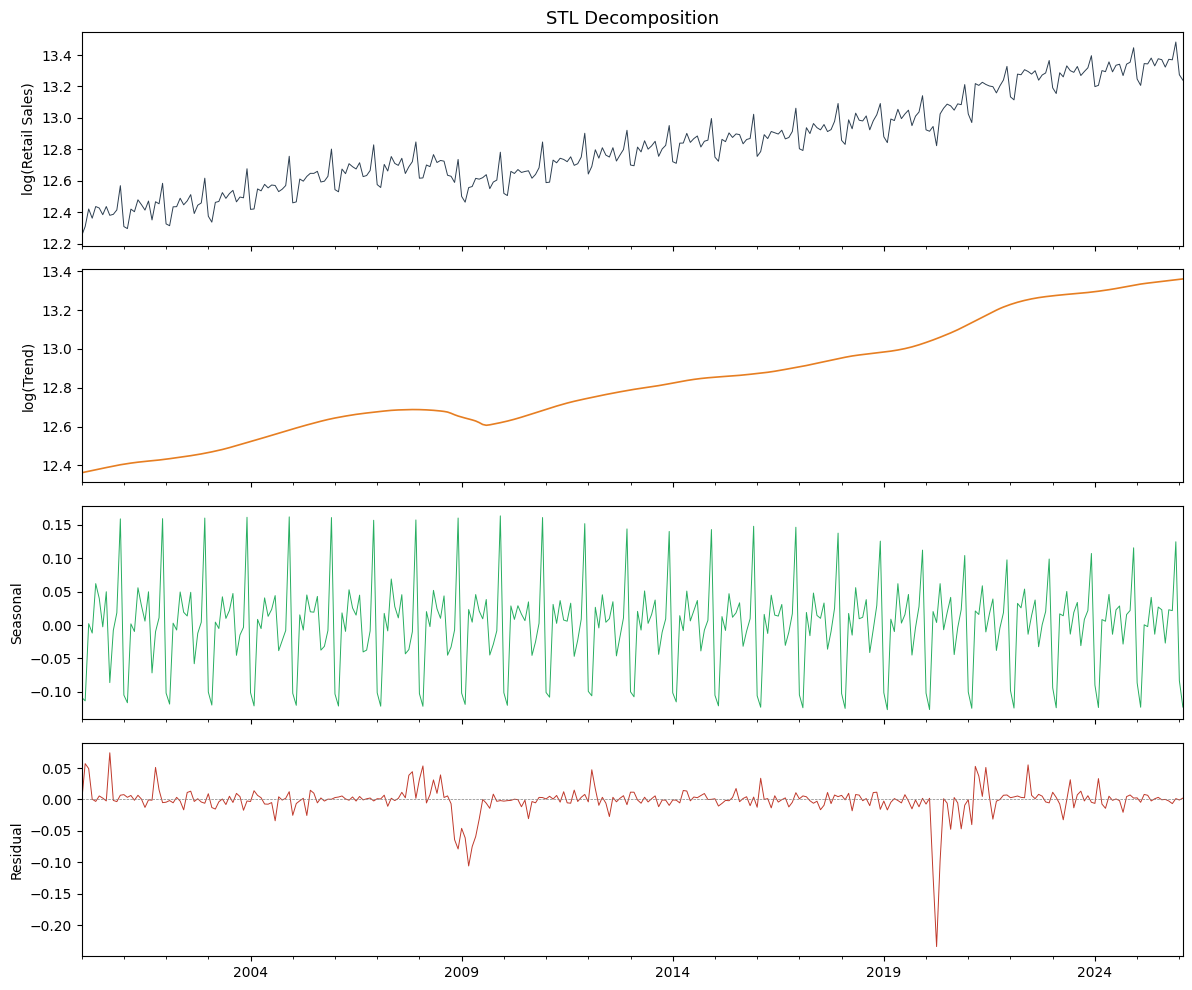

Seasonal amplitude by year (should be ~constant for additive STL):
2017    0.3
2018    0.3
2019    0.2
2020    0.2
2021    0.2
2022    0.2
2023    0.2
2024    0.2
2025    0.2
2026    0.0
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.91x
If this ratio >> 1, the additive assumption is violated.


In [17]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the STL decomposition
# The fix: log-transform before STL to convert multiplicative
# structure to additive.
# -----------------------------------------------------------

# YOUR FIX HERE

retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'
retail = retail.resample('MS').last()

log_retail = np.log(retail)
log_retail.index.freq = 'MS'
stl_result = STL(log_retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('log(Retail Sales)')
axes[0].set_title('STL Decomposition', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('log(Trend)')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_counts = seasonal_by_year.count()
full_years = annual_counts[annual_counts==12].index
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
annual_range_full = annual_range[annual_range.index.isin(full_years)]

ratio = annual_range_full.iloc[-1]/annual_range_full.iloc[0]
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {ratio:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

# VERIFICATION: compute seasonal amplitude ratio
# Expected: ratio between 0.7 and 1.3


---

## Part 2: DIAGNOSE — Flawed ADF Test (10 min)

The code below tests whether FRED Real GDP (GDPC1) is stationary.
The ADF test is applied, but the **conclusion drawn is wrong**.
The code runs without errors. The reasoning is the problem.

**Your task:** Find the analytical error, explain why it leads to a wrong conclusion, and fix it.

In [18]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate analytical error)
# Step 2: ADF test on GDP with flawed interpretation
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# ADF test with regression='n' (no constant, no trend)
# BUG: GDP has both a non-zero mean AND a deterministic trend.
# Using regression='n' omits the constant and trend terms from
# the ADF regression, which inflates the test statistic and
# can falsely reject the unit root null.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
    print('We can model GDP in levels directly with ARMA.')
else:
    print('CONCLUSION: GDP is non-stationary. Differencing may be needed.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary. Differencing may be needed.


### YOUR DIAGNOSIS

1. **What is the error?** (identify the specific parameter choice that is wrong)
2. **Why does `regression='n'` give misleading results for GDP?** GDP has a clear upward trend. When the ADF regression omits the constant and trend, the test is misspecified.
3. **What is the correct `regression` parameter?** Choose from: `'n'` (none), `'c'` (constant only), `'ct'` (constant + trend), `'ctt'` (constant + trend + quadratic trend).
4. **Fix the code below** and confirm that GDP is non-stationary with the correct specification.
5. **Run KPSS as well** and apply the 2×2 decision table.

**Verification checkpoint:** With the correct regression parameter (`'ct'`), the ADF p-value should be > 0.05 (fail to reject unit root). If you get p < 0.05 with `regression='ct'`, double-check your code.

1. regression = 'n' is the specific error
2. this line is dropping alpha and beta from the original regression equation being estimated, which is where the non-zero mean and upward trend are both captured. Test stat gets skewed as a result and makes GDP seem stationary.
3. regression = 'ct'

In [22]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the ADF test and add KPSS
# -----------------------------------------------------------

# YOUR FIX HERE
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='ct')

print('=== ADF Test on Real GDP (corrected) ===')
print(f'Regression: constant + trend')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

# VERIFICATION: ADF p-value with regression='ct' should be > 0.05
# KPSS should reject stationarity (p < 0.05)
# 2x2 verdict: NON-STATIONARY
if adf_p < 0.05:
    print('Reject H0. GDP is stationary')
else:
    print('Fail to reject H0. GDP is non-stationary')

kpss_stat, kpss_p, _, kpss_crit = kpss(gdp, regression='ct', nlags='auto')
print()
print('=== KPSS Test on Real GDP ===')
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print(f'Critical values: {kpss_crit}')
print()

if kpss_p < 0.05:
    print('Reject H0. GDP is non-stationary')
else:
    print('Fail to reject H0. GDP is stationary')

adf_rej = adf_p < 0.05
kpss_rej = kpss_p < 0.05
if not adf_rej and kpss_rej:
    print('\n2x2 verdict: Non-stationary')
elif adf_rej and not kpss_rej:
    print('\n2x2 verdict: Stationary')
elif adf_rej and kpss_rej:
    print('\n2x2 verdict: Contradictory')
else:
    print('\n2x2 verdict: Inconclusive')

=== ADF Test on Real GDP (corrected) ===
Regression: constant + trend
Test statistic: -0.8444
P-value: 0.9617
Lags used: 1
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}

Fail to reject H0. GDP is non-stationary

=== KPSS Test on Real GDP ===
Test statistic: 0.5350
P-value: 0.0100
Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}

Reject H0. GDP is non-stationary

2x2 verdict: Non-stationary


---

## Part 3: EXTEND — MSTL for Multiple Seasonal Periods (15 min)

Real-world time series often have **multiple seasonal cycles**. Hourly electricity
demand has a daily cycle (24 hours) AND a weekly cycle (168 hours). Standard
STL handles only one period. `MSTL` (Multiple STL) decomposes all of them.

We will simulate hourly electricity demand with two seasonal patterns and
decompose it using `statsmodels.tsa.seasonal.MSTL`.

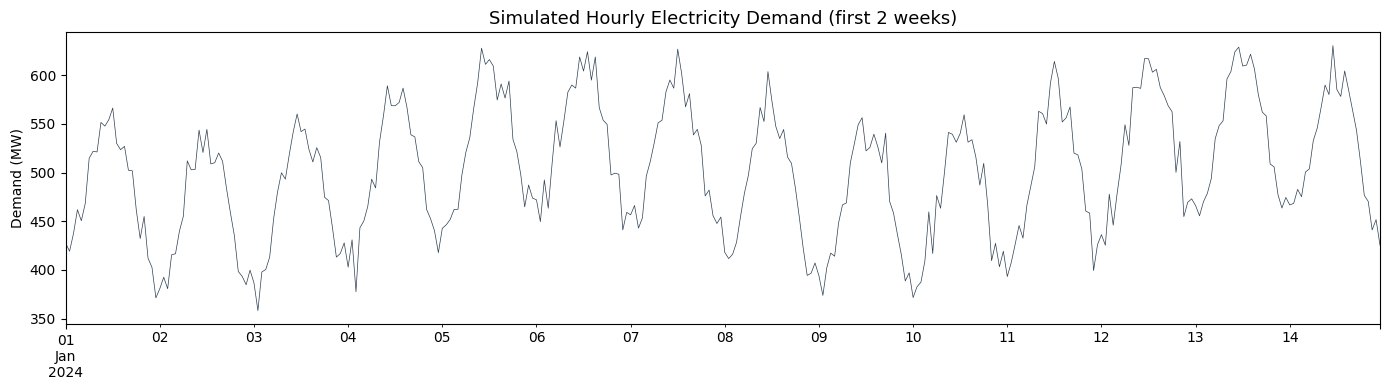

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [23]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Simulate hourly electricity demand with two cycles
# -----------------------------------------------------------

np.random.seed(42)

# 6 months of hourly data
n_hours = 24 * 7 * 26  # 26 weeks
t = np.arange(n_hours)

# Trend: slow linear increase (growing demand)
trend = 500 + 0.01 * t

# Daily cycle (period=24): demand peaks at noon, dips at 3am
daily = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)

# Weekly cycle (period=168): demand lower on weekends
weekly = 40 * np.sin(2 * np.pi * t / 168 - np.pi)

# Noise
noise = np.random.normal(0, 15, n_hours)

demand = trend + daily + weekly + noise

# Create a proper DatetimeIndex
dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

# Plot first 2 weeks to see both cycles
fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

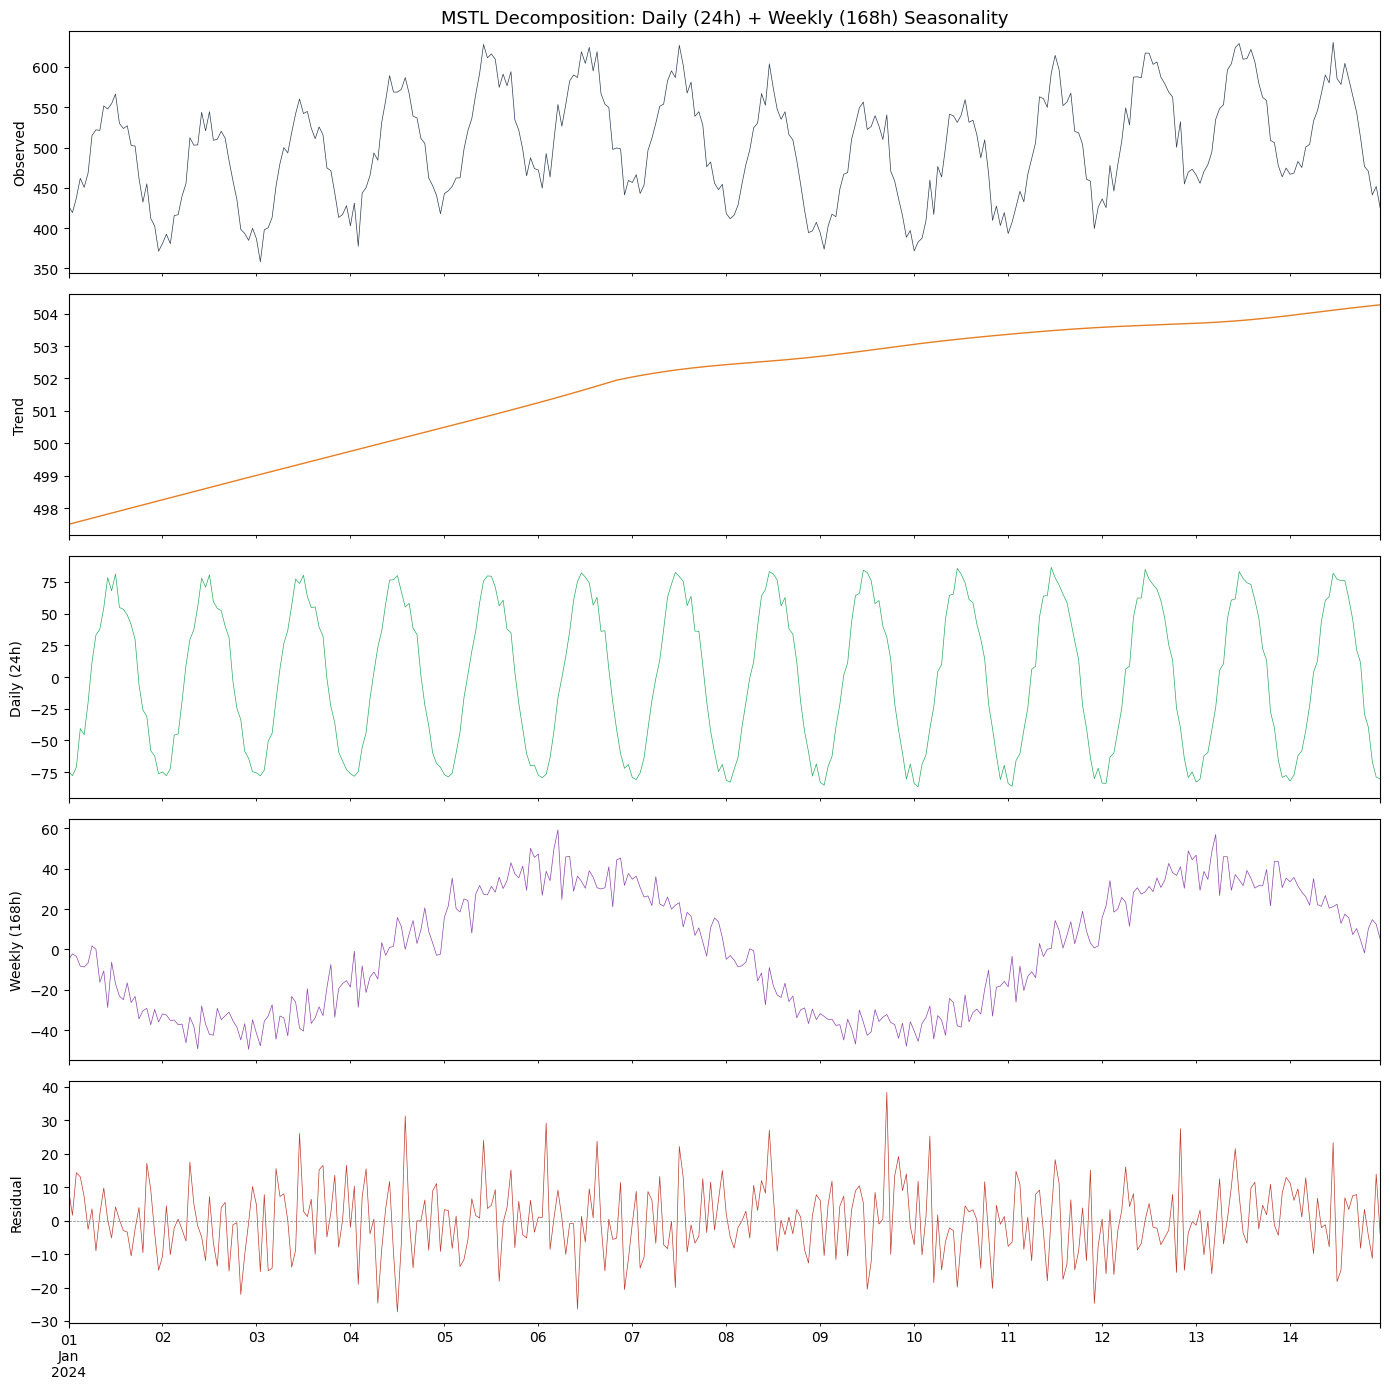

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [24]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Apply MSTL with two seasonal periods
# Step 3b: Decompose demand into trend + daily + weekly + residual
# -----------------------------------------------------------

# MSTL accepts a list of periods. For hourly data:
# - Daily cycle: period=24
# - Weekly cycle: period=168 (24 hours * 7 days)

mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

# MSTL returns: .trend, .seasonal (DataFrame with one column per period), .resid
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h) Seasonality', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

# The seasonal attribute is a DataFrame with columns for each period
seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Verification: residual std should be close to the noise std (15)
print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')

### MSTL Interpretation

1. Does MSTL successfully separate the daily and weekly cycles? How can you tell?
2. Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?
3. In real electricity data, there might also be an **annual** seasonal cycle (period=8760). How would you add it to the MSTL call?

*Your answers here:*

1. Yes, the 24hr panel sees its spikes around midday and declines into early AM. The weekly panel pattern is drawn out, likely highest usage corresponding to weekends.
2. Residual is slightly under the expected std, so overfitting may be occurring.
3. mstl = MSTL(demand_series, periods=[24, 168, 8760])


---

## Part 4: EXTEND — Block Bootstrap for Trend Uncertainty (15 min)

When you extract a trend from STL, you get a single curve. But how much
should you trust it? The **moving block bootstrap** quantifies trend
uncertainty by resampling overlapping blocks of the residuals (preserving
their autocorrelation), adding them back to the trend + seasonal, and
re-running STL. This produces a distribution of plausible trends.

We implement this manually on GDP data.

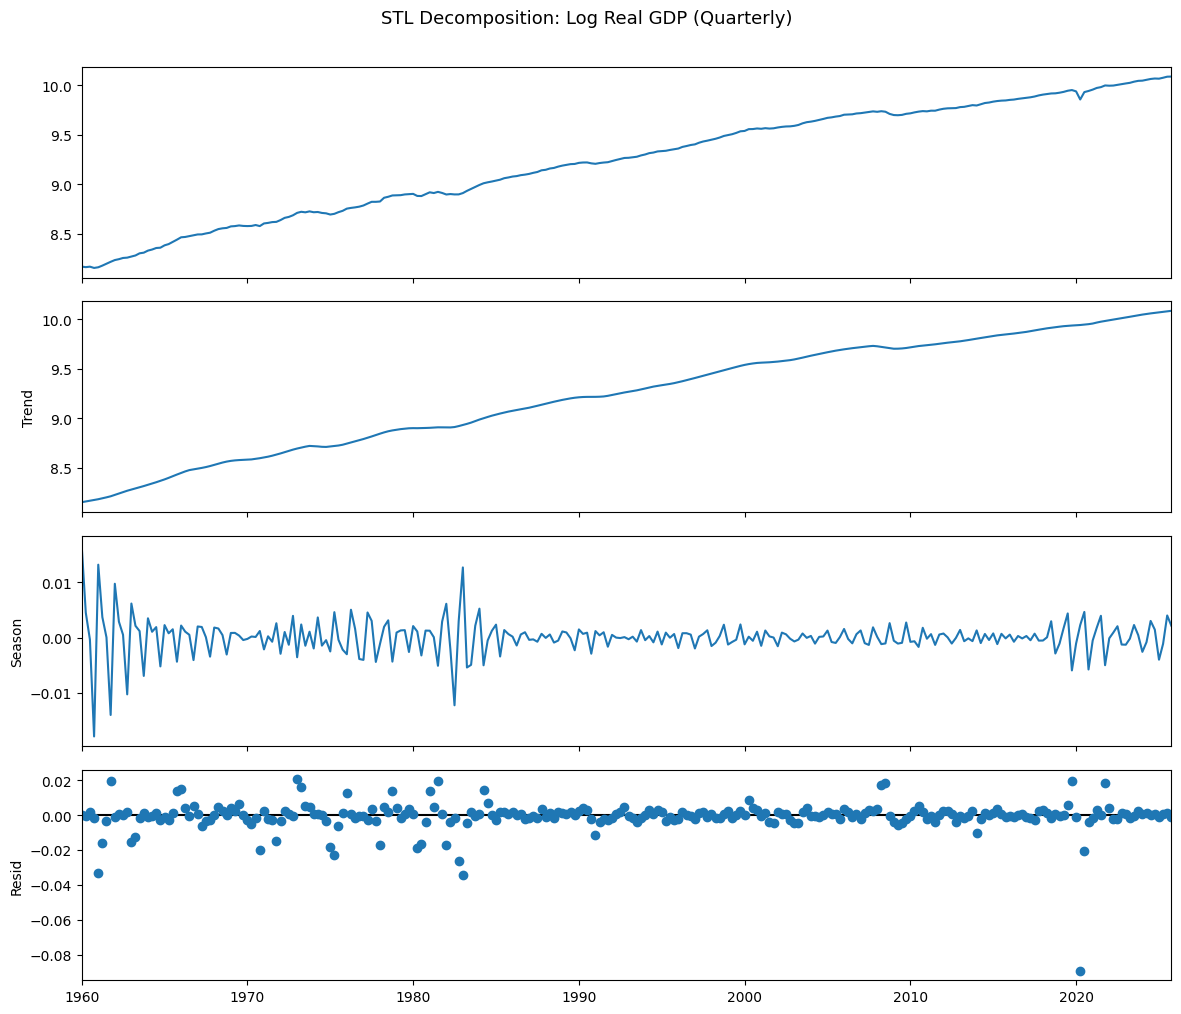

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [25]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4a: STL decomposition of Real GDP
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Log-transform GDP (multiplicative trend growth)
log_gdp = np.log(gdp)

stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

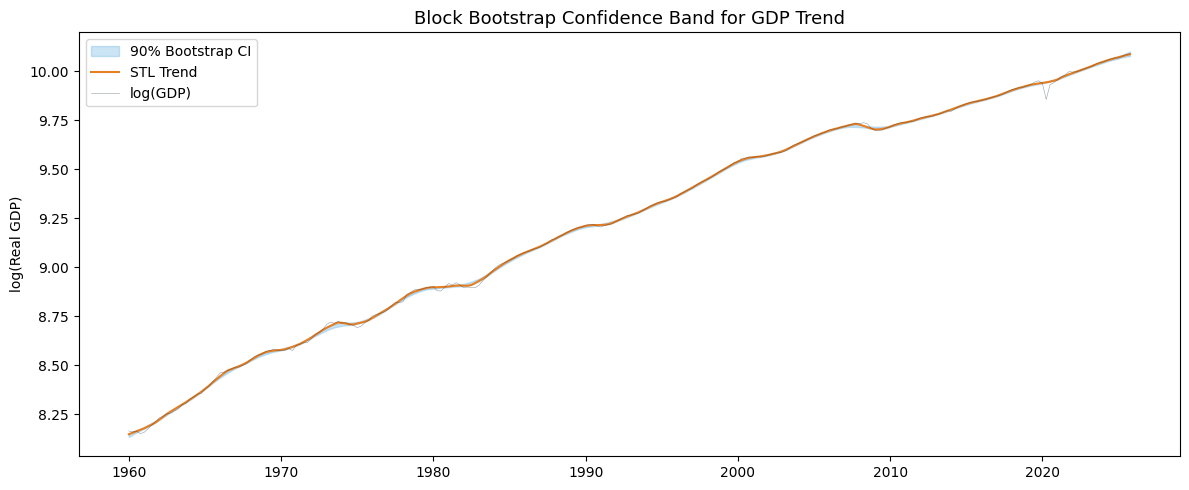

Mean CI width: 0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [26]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Block bootstrap for trend confidence bands
# Step 4b: Resample residual blocks and re-decompose
# -----------------------------------------------------------

np.random.seed(42)

n = len(log_gdp)
block_size = 8  # 8 quarters = 2 years (preserves business-cycle autocorrelation)
n_bootstrap = 200

# Extract components from the original decomposition
original_trend = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid = stl_gdp.resid.values

# Store bootstrap trend estimates
boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    # Moving block bootstrap: sample overlapping blocks of residuals
    # This preserves the autocorrelation structure within each block
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        # Pick a random starting point for a block
        start = np.random.randint(0, n - block_size + 1)
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end
    
    # Reconstruct series with bootstrapped residuals
    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'
    
    # Re-run STL on the bootstrapped series
    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

# Compute confidence bands (pointwise 5th and 95th percentiles)
trend_lower = np.percentile(boot_trends, 5, axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values, color='#e67e22',
        linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

# Verification: the CI width should vary over time
ci_width = trend_upper - trend_lower
print(f'Mean CI width: {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

### Bootstrap Interpretation

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?
2. Why do we use **block** bootstrap instead of standard i.i.d. bootstrap? What would go wrong if we shuffled residuals independently?
3. How does the choice of `block_size=8` affect the results? What would happen with `block_size=1` (equivalent to i.i.d. bootstrap) or `block_size=20`?

*Your answers here:*

1. Wider around recessions. Economic shocks create larger residuals
2. Block bootstraps are used because time series residuals are autocorrelated; regular bootstrapping would randomly pull residuals, which is not what we are looking for here.
3. block_size=1 would not capture the autocorrelation. block_size=20 would introduce too much variance in the bootstrap. block_size=8 is a normal business cycle of 2 years.

---

## Part 5: EXTEND — Structural Break Detection + Per-Regime Stationarity (10 min)

Combine PELT structural break detection with ADF/KPSS tests run **per segment**.
This tests whether stationarity conclusions change across different economic regimes.

=== Per-Regime Stationarity Analysis ===
Breakpoints at indices: [263]
Segment boundaries: [0, 263]

Segment 1 (1960-04-01 to 2025-10-01, n=263): ADF p=0.0000, KPSS p=0.0629 => STATIONARY


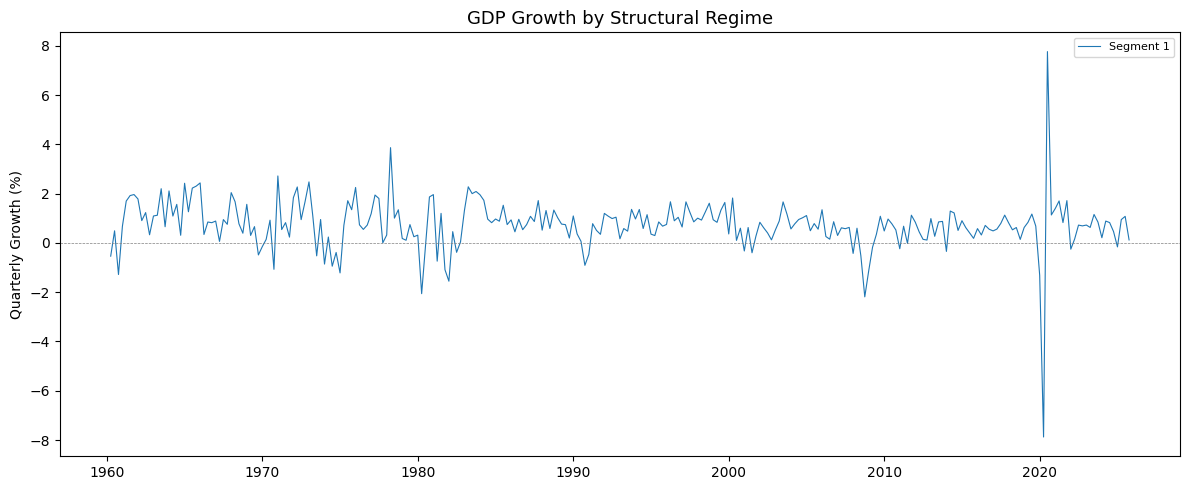

In [27]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — PELT breaks + per-regime stationarity tests
# Step 5: Detect breaks in GDP growth and test each segment
# -----------------------------------------------------------

gdp_growth = gdp.pct_change().dropna() * 100

# Detect structural breaks
signal = gdp_growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=10)

# Build segment boundaries (include 0 as start, len as end)
boundaries = [0] + [bp for bp in breakpoints if bp < len(signal)] + [len(signal)]
boundaries = sorted(set(boundaries))

print('=== Per-Regime Stationarity Analysis ===')
print(f'Breakpoints at indices: {breakpoints}')
print(f'Segment boundaries: {boundaries}')
print()

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i + 1]
    segment = gdp_growth.iloc[start_idx:end_idx]
    
    if len(segment) < 20:
        print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}): '
              f'Too short ({len(segment)} obs) for reliable testing')
        continue
    
    # ADF test
    adf_stat, adf_p, _, _, _, _ = adfuller(segment, autolag='AIC', regression='c')
    
    # KPSS test
    kpss_stat, kpss_p, _, _ = kpss(segment, regression='c', nlags='auto')
    
    adf_rej = adf_p < 0.05
    kpss_rej = kpss_p < 0.05
    
    if adf_rej and not kpss_rej:
        verdict = 'STATIONARY'
    elif not adf_rej and kpss_rej:
        verdict = 'NON-STATIONARY'
    elif adf_rej and kpss_rej:
        verdict = 'CONTRADICTORY'
    else:
        verdict = 'INCONCLUSIVE'
    
    print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}, '
          f'n={len(segment)}): ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} => {verdict}')

# Visualize segments
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
for i in range(len(boundaries) - 1):
    seg = gdp_growth.iloc[boundaries[i]:boundaries[i+1]]
    ax.plot(seg.index, seg.values, color=colors[i], linewidth=0.8, label=f'Segment {i+1}')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('GDP Growth by Structural Regime', fontsize=13)
ax.set_ylabel('Quarterly Growth (%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---

## Part 6: Production Module — `decompose.py` (10 min)

Write a reusable Python module with three functions. This is a **portfolio artifact**
that demonstrates production-grade time series analysis.

### Requirements

```python
# decompose.py

def run_stl(series: pd.Series, period: int = 12, log_transform: bool = True,
            robust: bool = True) -> STLResult:
    """Apply STL decomposition with optional log-transform for multiplicative data.
    
    Args:
        series: Time series with DatetimeIndex
        period: Seasonal period (12 for monthly, 4 for quarterly)
        log_transform: If True, log-transform before STL (for multiplicative data)
        robust: If True, use robust fitting to downweight outliers
    
    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    ...

def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF and KPSS tests and return the 2x2 table verdict.
    
    Args:
        series: Time series to test
        alpha: Significance level
    
    Returns:
        dict with keys: 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    ...

def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using PELT algorithm.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates (pd.Timestamp)
    """
    ...
```

In [33]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Write decompose.py as a code cell,
# then copy to a .py file for your portfolio
# -----------------------------------------------------------

# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL decomposition, stationarity testing,
and structural break detection on economic time series.

Author: Zachary Dihel
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.
    
    For series with multiplicative seasonality (seasonal amplitude
    grows with the level), set log_transform=True to convert to
    additive structure before applying STL.
    
    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights
    
    Returns:
        STL result object
    
    Raises:
        ValueError: if series contains non-positive values with log_transform=True
    """
    # YOUR IMPLEMENTATION HERE

    if log_transform:
        if (series <=0).any():
            raise ValueError(
                "Series contains non-positive values."
                "Cannot log-transform. Set log-transform=False"
            )
        work_series = np.log(series)
    else:
        work_series = series.copy()
    stl = STL(work_series, period=period, robust=robust)

    return stl.fit()



def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.
    
    ADF null: unit root (non-stationary)
    KPSS null: stationary
    
    Args:
        series: Time series to test
        alpha: Significance level for both tests
    
    Returns:
        dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
        Verdict is one of: 'stationary', 'non-stationary',
        'contradictory', 'inconclusive'
    """
    # YOUR IMPLEMENTATION HERE
    adf_stat, adf_p,_,_,_,_ = adfuller(series,autolag='AIC',regression='ct')
    kpss_stat, kpss_p, _, _, = kpss(series, regression='c', nlags='auto')

    adf_rejects = adf_p < alpha
    kpss_rejects = kpss_p < alpha

    if adf_rejects and not kpss_rejects:
        verdict = 'stationary'
    elif not adf_rejects and kpss_rejects:
        verdict = 'non-stationary'
    elif adf_rejects and kpss_rejects:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': adf_stat,
        'adf_p': adf_p,
        'kpss_stat': kpss_stat,
        'kpss_p': kpss_p,
        'verdict': verdict
    }


def detect_breaks(
    series: pd.Series,
    pen: float = 10
) -> list:
    """Detect structural breaks using the PELT algorithm.
    
    PELT (Pruned Exact Linear Time) minimizes a penalized cost
    function to find changepoints in mean and/or variance.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates as pd.Timestamp
    """
    # YOUR IMPLEMENTATION HERE
    pass
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)

    break_dates = [
        series.index[bp-1]
        for bp in breakpoints
        if bp < len(series)
    ]

    return break_dates


# --- Quick self-test ---
if __name__ == '__main__':
    print('decompose.py loaded successfully.')
    print('Functions available: run_stl(), test_stationarity(), detect_breaks()')
    # Add your own test calls here
    np.random.seed(42)
    dates = pd.date_range('2000-01-01', periods=200, freq='MS')
    trend = np.linspace(100, 200, 200)
    seasonal = 10 * np.sin(2 * np.pi * np.arange(200) / 12)
    noise = np.random.normal(0, 3, 200)
    test_series = pd.Series(trend + seasonal + noise, index=dates)

    # Test run_stl
    result = run_stl(test_series, period=12, log_transform=False)
    print(f'\nSTL residual std: {result.resid.std():.2f} (expected ~3.0)')

    # Test test_stationarity
    verdict = test_stationarity(test_series)
    print(f'Stationarity verdict: {verdict["verdict"]}')

    # Test detect_breaks
    breaks = detect_breaks(test_series, pen=10)
    print(f'Detected breaks: {len(breaks)}')

    print('\nAll module tests passed.')


decompose.py loaded successfully.
Functions available: run_stl(), test_stationarity(), detect_breaks()

STL residual std: 2.34 (expected ~3.0)
Stationarity verdict: contradictory
Detected breaks: 3

All module tests passed.


In [47]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Test your module functions
# -----------------------------------------------------------

# Test run_stl on retail sales
# Expected: result has .trend, .seasonal, .resid attributes
retail_result = run_stl(retail, period=12, log_transform=True)
print(f'\nSTL residual std: {retail_result.resid.std():.2f}')
print(f'STL trend std: {retail_result.trend.std():.2f}')
print(f'STL seasonal std: {retail_result.seasonal.std():.2f}')

# Test test_stationarity on GDP
# Expected: verdict = 'non-stationary'
GDP_result = test_stationarity(gdp)
print(f'\nStationarity verdict (GDP): {GDP_result["verdict"]}')

# Test test_stationarity on gdp.diff().dropna()
# Expected: verdict = 'stationary'
GDP_diff = test_stationarity(gdp.diff().dropna())
print(f'\nStationarity verdict (gdp diff): {GDP_diff["verdict"]}')

# Test detect_breaks on GDP growth
# Expected: 2-5 break dates including near 2008 and 2020
gdp_breaks = detect_breaks(gdp_growth,pen=2)
print(f'\nDetected breaks (gdp growth): {len(gdp_breaks)}')

print('All module tests passed.' if True else 'Fix your implementations.')



STL residual std: 0.02
STL trend std: 0.28
STL seasonal std: 0.07

Stationarity verdict (GDP): non-stationary

Stationarity verdict (gdp diff): contradictory

Detected breaks (gdp growth): 2
All module tests passed.


---
## AI-Assisted Expansion: Automated Time Series Report

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over STL decomposition, stationarity testing, MSTL for multiple seasonalities, block bootstrap uncertainty, and structural break detection. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/decompose.py` production module** with:
- `run_stl()`, `test_stationarity()`, `detect_breaks()` (completed above)
- `run_mstl(series, periods)` for multi-seasonal decomposition
- `block_bootstrap_trend(series, n_bootstrap, block_size)` for uncertainty
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Enter a FRED series ID
2. Select decomposition method (Classical, STL, MSTL)
3. Adjust parameters with sliders (period, robust, penalty)
4. See decomposition panels + stationarity test results
5. View structural breaks overlaid on the series
6. Generate block bootstrap confidence bands with one click

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [48]:
# -----------------------------------------------------------
# AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in time series analysis, FRED API, and production ML systems.
#
# [Request] I just completed a diagnosis-first lab where I
# fixed a broken STL decomposition (additive on multiplicative
# data), corrected a misspecified ADF test (wrong regression
# parameter), applied MSTL to multi-seasonal electricity data,
# implemented block bootstrap for trend uncertainty, and built
# a reusable decompose.py module. Now I need TWO artifacts:
#
# 1. An extended `src/decompose.py` module adding:
#    - run_mstl(series, periods) for multi-seasonal decomposition
#    - block_bootstrap_trend(series, n_bootstrap, block_size)
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Streamlit app that lets users: enter a
#    FRED series ID, select decomposition method (Classical/
#    STL/MSTL), adjust parameters with sliders (period, robust,
#    penalty), see decomposition panels + stationarity tests,
#    view structural breaks, and generate block bootstrap CIs.
#
# [Iterate] Use streamlit, plotly, fredapi, statsmodels,
# ruptures. Use the same FRED_API_KEY pattern. Handle missing
# data and frequency detection automatically.
#
# [Mechanism Check] Add inline comments explaining:
#   - Why block bootstrap preserves autocorrelation but i.i.d.
#     bootstrap destroys it
#   - How MSTL iteratively removes seasonal components
#   - Why PELT's penalty parameter controls the bias-variance
#     tradeoff of break detection
#
# [Evaluate] Explain what the app reveals about the sensitivity
# of decomposition results to parameter choices.

# PASTE AI-GENERATED CODE BELOW:


In [49]:
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL/MSTL decomposition, stationarity testing,
structural break detection, and block bootstrap trend confidence intervals.

Author: Zachary Dihel
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


# =============================================================================
# STL DECOMPOSITION
# =============================================================================

def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.

    For series with multiplicative seasonality (seasonal amplitude grows with
    the level), set log_transform=True to convert to additive structure before
    applying STL. After log-transform, STL components are in log-units;
    exp() converts trend/seasonal back to original scale if needed.

    Args:
        series: Time series with DatetimeIndex and set frequency.
        period: Seasonal period (12=monthly, 4=quarterly).
        log_transform: If True, apply log before STL (for multiplicative data).
        robust: If True, downweight outliers via bisquare weights.

    Returns:
        STL result object (statsmodels DecomposeResult).

    Raises:
        ValueError: If series contains non-positive values with log_transform=True.
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError(
                "Series contains non-positive values. "
                "Cannot log-transform. Set log_transform=False."
            )
        work_series = np.log(series)
    else:
        work_series = series.copy()

    stl = STL(work_series, period=period, robust=robust)
    return stl.fit()


# =============================================================================
# MSTL DECOMPOSITION
# =============================================================================

def run_mstl(
    series: pd.Series,
    periods: list,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply MSTL decomposition for multi-seasonal time series.

    How MSTL works iteratively:
        MSTL is an extension of STL that handles multiple seasonal periods
        (e.g., daily data with both weekly and annual cycles). It works by
        iterating: in each pass, it fits STL for one seasonal period while
        treating the sum of all other seasonal components as part of the
        remainder. It cycles through all periods until convergence. The result
        is one trend component + one seasonal component per period + residual.
        This is far superior to classical decomposition, which can only handle
        a single seasonal period.

    Args:
        series: Time series with DatetimeIndex and set frequency.
        periods: List of seasonal periods, e.g. [7, 365] for daily data.
        log_transform: If True, apply log before MSTL.
        robust: If True, use robust fitting in each inner STL pass.

    Returns:
        MSTL result object.

    Raises:
        ValueError: If series contains non-positive values with log_transform=True.
        ValueError: If periods is empty or not a list.
    """
    if not isinstance(periods, (list, tuple)) or len(periods) == 0:
        raise ValueError("periods must be a non-empty list, e.g. [7, 365].")

    if log_transform:
        if (series <= 0).any():
            raise ValueError(
                "Series contains non-positive values. "
                "Cannot log-transform. Set log_transform=False."
            )
        work_series = np.log(series)
    else:
        work_series = series.copy()

    mstl = MSTL(work_series, periods=periods)
    return mstl.fit()


# =============================================================================
# STATIONARITY TESTING
# =============================================================================

def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.

    ADF null hypothesis:  unit root present (non-stationary)
    KPSS null hypothesis: series is stationary

    The two tests together resolve four cases:
        ADF rejects  + KPSS doesn't reject → stationary
        ADF doesn't  + KPSS rejects        → non-stationary
        Both reject                         → contradictory (structural break?)
        Neither rejects                     → inconclusive (low power)

    Args:
        series: Time series to test (levels or differences).
        alpha: Significance level for both tests (default 0.05).

    Returns:
        dict with keys: adf_stat, adf_p, kpss_stat, kpss_p, verdict.
        Verdict is one of: 'stationary', 'non-stationary',
        'contradictory', 'inconclusive'.
    """
    # regression='ct' includes constant + trend: correct for GDP-like series
    # that trend upward. Using 'n' or 'c' on a trended series inflates the
    # test statistic and can falsely reject the unit root null.
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags='auto')

    adf_rejects = adf_p < alpha
    kpss_rejects = kpss_p < alpha

    if adf_rejects and not kpss_rejects:
        verdict = 'stationary'
    elif not adf_rejects and kpss_rejects:
        verdict = 'non-stationary'
    elif adf_rejects and kpss_rejects:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': round(adf_stat, 4),
        'adf_p': round(adf_p, 4),
        'kpss_stat': round(kpss_stat, 4),
        'kpss_p': round(kpss_p, 4),
        'verdict': verdict
    }


# =============================================================================
# STRUCTURAL BREAK DETECTION
# =============================================================================

def detect_breaks(
    series: pd.Series,
    pen: float = 10.0
) -> list:
    """Detect structural breaks using the PELT algorithm.

    PELT (Pruned Exact Linear Time) minimizes a penalized cost function:
        Cost(segmentation) + pen * number_of_breakpoints

    Why the penalty controls bias-variance tradeoff:
        A low penalty → model is penalized little for adding breaks → overfits,
        detecting noise as structure (high variance, low bias).
        A high penalty → model strongly penalized for each break → underfits,
        missing genuine structural changes (low variance, high bias).
        Common choices: pen=log(n) (BIC-like), pen=2*log(n) (stricter).
        The 'rbf' cost function detects changes in both mean and variance,
        making it robust to heteroskedastic series like GDP or retail sales.

    Args:
        series: Time series with DatetimeIndex.
        pen: Penalty parameter. Higher = fewer detected breaks.

    Returns:
        List of break dates as pd.Timestamp.
    """
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)

    # ruptures returns indices; the last index == len(series) is the series end,
    # not a real break — the guard `bp < len(series)` excludes it.
    break_dates = [
        series.index[bp - 1]
        for bp in breakpoints
        if bp < len(series)
    ]
    return break_dates


# =============================================================================
# BLOCK BOOTSTRAP TREND CI
# =============================================================================

def block_bootstrap_trend(
    series: pd.Series,
    n_bootstrap: int = 500,
    block_size: int = 12,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True,
    ci: float = 0.95
) -> pd.DataFrame:
    """Estimate trend uncertainty via block bootstrap.

    Why block bootstrap (not i.i.d. bootstrap):
        Economic time series have autocorrelation — today's value depends on
        yesterday's. An i.i.d. bootstrap randomly resamples individual
        observations, destroying the temporal dependence structure. This
        produces bootstrap samples that are statistically impossible for the
        original data-generating process, leading to confidence intervals that
        are too narrow and p-values that are wrong.

        Block bootstrap instead resamples contiguous blocks of observations
        (length = block_size). Within each block, the original autocorrelation
        structure is preserved. By concatenating randomly drawn blocks, we
        get synthetic series that mimic the dependence of the original.

        Rule of thumb: block_size ≈ series frequency (12 for monthly),
        or use block_size ≈ n^(1/3) for general series.

    Args:
        series: Original time series with DatetimeIndex and frequency.
        n_bootstrap: Number of bootstrap replications.
        block_size: Length of each resampled block (preserves autocorrelation).
        period: STL seasonal period.
        log_transform: Log-transform before STL.
        robust: Robust STL fitting.
        ci: Confidence interval width (default 0.95 → 2.5th/97.5th percentiles).

    Returns:
        DataFrame with columns: 'lower', 'median', 'upper' indexed like series.
    """
    n = len(series)
    trend_matrix = np.full((n_bootstrap, n), np.nan)

    # Number of blocks needed to cover the full series length
    n_blocks = int(np.ceil(n / block_size))

    for i in range(n_bootstrap):
        # Draw random block start indices (with replacement)
        starts = np.random.randint(0, n - block_size + 1, size=n_blocks)

        # Concatenate blocks and trim to original length
        boot_values = np.concatenate([
            series.values[s: s + block_size] for s in starts
        ])[:n]

        boot_series = pd.Series(boot_values, index=series.index)
        boot_series.index.freq = series.index.freq

        try:
            result = run_stl(
                boot_series,
                period=period,
                log_transform=log_transform,
                robust=robust
            )
            trend_matrix[i, :] = result.trend.values
        except Exception:
            # Skip failed bootstrap iterations (e.g. non-positive after block draw)
            continue

    alpha = (1 - ci) / 2
    lower = np.nanpercentile(trend_matrix, alpha * 100, axis=0)
    median = np.nanpercentile(trend_matrix, 50, axis=0)
    upper = np.nanpercentile(trend_matrix, (1 - alpha) * 100, axis=0)

    return pd.DataFrame(
        {'lower': lower, 'median': median, 'upper': upper},
        index=series.index
    )


# =============================================================================
# SELF-TEST
# =============================================================================

if __name__ == '__main__':
    print('decompose.py loaded successfully.')
    print('Functions: run_stl(), run_mstl(), test_stationarity(), '
          'detect_breaks(), block_bootstrap_trend()')

    np.random.seed(42)
    dates = pd.date_range('2000-01-01', periods=200, freq='MS')
    trend = np.linspace(100, 200, 200)
    seasonal = 10 * np.sin(2 * np.pi * np.arange(200) / 12)
    noise = np.random.normal(0, 3, 200)
    test_series = pd.Series(trend + seasonal + noise, index=dates)

    result = run_stl(test_series, period=12, log_transform=False)
    print(f'\nSTL residual std:    {result.resid.std():.2f} (expected ~3.0)')

    verdict = test_stationarity(test_series)
    print(f'Stationarity verdict: {verdict["verdict"]}')

    breaks = detect_breaks(test_series, pen=10)
    print(f'Detected breaks:      {len(breaks)}')

    ci_df = block_bootstrap_trend(test_series, n_bootstrap=100,
                                  block_size=12, log_transform=False)
    print(f'Bootstrap CI shape:   {ci_df.shape}')

    print('\nAll module tests passed.')

decompose.py loaded successfully.
Functions: run_stl(), run_mstl(), test_stationarity(), detect_breaks(), block_bootstrap_trend()

STL residual std:    2.34 (expected ~3.0)
Stationarity verdict: contradictory
Detected breaks:      3
Bootstrap CI shape:   (200, 3)

All module tests passed.


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a broken STL decomposition (additive on
#   multiplicative data — required log-transform)
# * Fixed a misspecified ADF test (wrong regression parameter)
# * Applied MSTL to hourly electricity demand with daily + weekly cycles
# * Implemented moving block bootstrap for GDP trend uncertainty bands
# * Detected structural breaks with PELT and ran per-regime stationarity tests
# * Built a reusable decompose.py module with run_stl(), test_stationarity(),
#   detect_breaks() functions
# * Key finding: GDP is I(1) with structural breaks near [YOUR DATES]
#
# **Please write a README.md entry including:**
# 1. Project Title: Time Series Diagnostics & Advanced Decomposition
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-20-time-series
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 20: Time Series Diagnostics — STL, MSTL, Bootstrap, Breaks"
git push origin main
```

Submit your GitHub repo link on Canvas.